In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
drivers = pd.read_csv('drivers.csv')
passengers = pd.read_csv('passengers.csv')
taxi_2 = pd.read_csv('taxi_2.csv')

#Объединим таблицы drivers и passengers с помощью merge()
#И склеим ретью таблицу taxi_2 с помощью pd.concat()

taxi = drivers.merge(passengers, on='journey_id')
taxi = pd.concat([taxi,taxi_2]).reset_index()
taxi.head()


,index,journey_id,driver_id,taxi_id,icon,start_at,end_at,end_lat,end_lon,end_state,driver_start_lat,driver_start_lon,arrived_at,rider_score,user_id,start_type,start_lat,start_lon,source,driver_score
0,0,23a1406fc6a11d866e3c82f22eed4d4c,583949a89a9ee17d19e3ca4f137b6b4c,b12f4f09c783e29fe0d0ea624530db56,executive,2010-11-16 16:44:00,2010-11-16 17:29:00,"-12,05537033","-77,0413208",drop off,"-12,10825481","-77,0272739",2010-11-16 17:02:00,5.0,0e9af5bbf1edfe591b54ecdfd7e91e26,asap,"-12,13983536","-77,02355957",iPhone,5.0
1,1,dd2af4715d0dc16eded53afc0e243577,NaN,NaN,executive,2010-06-01 00:34:00,2010-06-01 00:37:00,"-12,12465668","-77,02886963",not found,NaN,NaN,NaN,NaN,a553c46e3a22fb9c326aeb3d72b3334e,asap,"-12,13874817","-76,99536133",iPhone,NaN
2,2,dd91e131888064bf7df3ce08f3d4b4ad,NaN,NaN,executive,2010-05-31 05:01:00,2010-05-31 05:04:00,"-12,13883209","-76,99530029",not found,NaN,NaN,NaN,NaN,a553c46e3a22fb9c326aeb3d72b3334e,asap,"-12,12453079","-77,02780151",iPhone,NaN
3,3,dd2af4715d0dc16eded53afc0e2466d0,NaN,NaN,executive,2010-06-01 00:29:00,2010-06-01 00:32:00,"-12,12458801","-77,02896118",not found,NaN,NaN,NaN,NaN,a553c46e3a22fb9c326aeb3d72b3334e,asap,"-12,13885117","-76,99530029",iPhone,NaN
4,4,85b7eabcf5d84e42dc7629b7d27781af,d665fb9f75ef5d9cd0fd89479380ba78,0accdd3aa5a322f4129fa20b53278c69,executive,2010-09-11 23:55:00,2010-09-12 01:07:00,"-12,02223206","-77,10638428",drop off,"-12,08311558","-76,9277072",2010-09-11 23:50:00,5.0,56772d544fdfa589a020a1ff894a86f7,reserved,"-12,08995438","-76,92626953",iPhone,4.0


In [2]:
#Проверим в есть ли пропущенные занчения в таблице и как много. Нужно найти колонку, где пропущенных
#значений наибольшее колличество.


taxi.isna().sum().idxmax()

'driver_score'

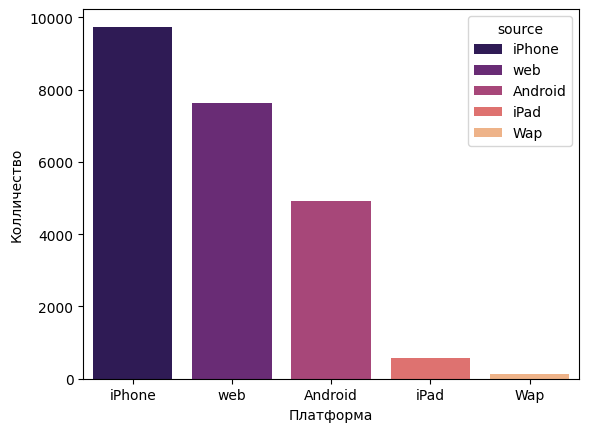

In [155]:
#Перейдем к анализу этих платформ. Определим долю заказов, сделанных с той или иной платформы. 
# У какой платформы эта доля самая большая? 
#В ответе укажим значение наибольшей доли заказов в %, округлённое до целого.


percent_count = (taxi['source'].value_counts(normalize=True).round(2) * 100).reset_index()
source_count = taxi['source'].value_counts().reset_index()
source = source_count.merge(percent_count, on='source', how='inner').rename(columns={'count_x': 'count', 'count_y': 'percent'})
sns.color_palette("magma", as_cmap=False)
sns.barplot(data=source, x='source', y='count', palette='magma', hue='source', legend=True)
plt.xlabel('Платформа')
plt.ylabel('Колличество')
plt.show()
#Агрегируем данные и постройте барчарт, где по оси x будет расположено название платформы 
# (source), а по оси y – количество заказов (абсолютные значения, не доля).




<Axes: xlabel='source', ylabel='count'>

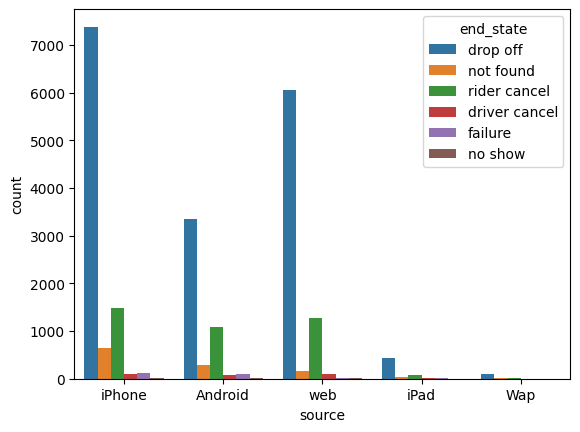

In [156]:
#Более детально проанализируем распределение заказов по платформам. 
# С помощью функции sns.countplot и параметра 
# hue визуализируем распределение переменной end_state (итоговое состояние заказа) в 
# разбивке по платформам (см.колонку source).

sns.countplot(data=taxi, x='source', hue='end_state')

In [147]:
#Больше всего заказов со статусом drop off совершено с платформы iPhone
#На Android количество отмененных поездок (rider cancel) меньше, чем на iPhone
#Наибольшая разница между количеством drop off и rider cancel наблюдается для платформы iPhone


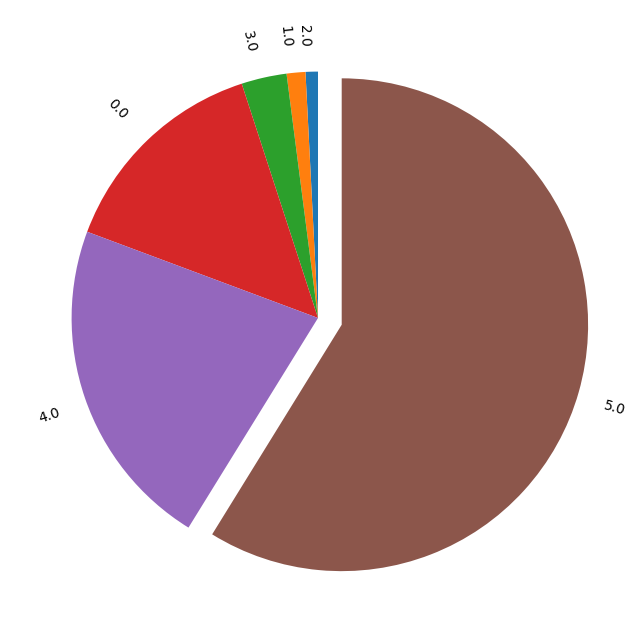

In [157]:
#С платформами разобрались. Теперь давайте перейдем к анализу оценок, которые ставят пассажиры 
# водителям и водители пассажирам.
#Проверим, как распределены оценки водителей (см.колонку driver_score).


driver_score_counts = taxi['driver_score'].value_counts(normalize=True)\
    .mul(100)\
        .round(2).reset_index()\
            .rename(columns={'proportion': 'percentage'})\
            .sort_values('percentage')
plt.figure(figsize=(8,8))
plt.pie(data=driver_score_counts, x='percentage', labels='driver_score', startangle=90, explode=[0,0,0,0,0,0.1], rotatelabels=True)
plt.show()

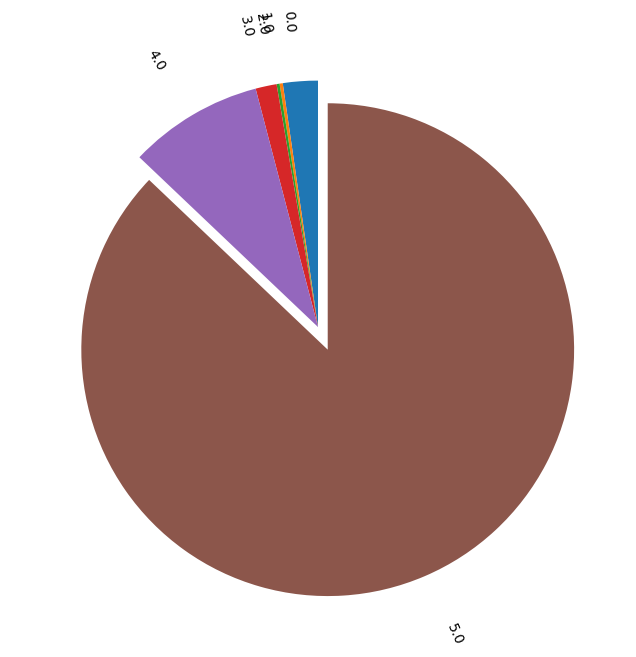

In [158]:
#Сейчас повторим процесс и проанализируем оценки водителями пассажиров 
# (см.колонку rider_score). 
# Сравним распределение этих оценок с распределением оценок водителей.


rider_score_counts = taxi['rider_score']\
    .value_counts(normalize=True)\
        .mul(100).reset_index()\
            .rename(columns={'proportion': 'percent'})\
            .sort_values('rider_score')
plt.figure(figsize=(8,8))
plt.pie(data=rider_score_counts, x='percent', labels='rider_score', startangle=90, explode=[0,0,0,0,0,0.1], rotatelabels=True, pctdistance=0.8, labeldistance=1.2 )
plt.show()

In [192]:
#Более чем в 80% случаев водители поставили клиентам 5 звездочек
#Водители ставят меньше оценок 0, чем клиенты


In [159]:
#Теперь перейдем к анализу временных данных. Но перед этим приведем столбцы start_at, end_at, arrived_at к формату даты и времени, 
# используя pd.to_datetime. Отфильтруем данные и оставим наблюдения со статусами заказа "asap" и "reserved" (см.колонку start_type). 
# Результат сохраним в тот же датафрейм taxi

taxi[['start_at', 'end_at', 'arrived_at']] = taxi[['start_at', 'end_at', 'arrived_at']].apply(pd.to_datetime)
taxi.query('start_type == "asap" or start_type == "reserved"')


,index,journey_id,driver_id,taxi_id,icon,start_at,end_at,end_lat,end_lon,end_state,driver_start_lat,driver_start_lon,arrived_at,rider_score,user_id,start_type,start_lat,start_lon,source,driver_score
0,0,23a1406fc6a11d866e3c82f22eed4d4c,583949a89a9ee17d19e3ca4f137b6b4c,b12f4f09c783e29fe0d0ea624530db56,executive,2010-11-16 16:44:00,2010-11-16 17:29:00,"-12,05537033","-77,0413208",drop off,"-12,10825481","-77,0272739",2010-11-16 17:02:00,5.0,0e9af5bbf1edfe591b54ecdfd7e91e26,asap,"-12,13983536","-77,02355957",iPhone,5.0
1,1,dd2af4715d0dc16eded53afc0e243577,NaN,NaN,executive,2010-06-01 00:34:00,2010-06-01 00:37:00,"-12,12465668","-77,02886963",not found,NaN,NaN,NaT,NaN,a553c46e3a22fb9c326aeb3d72b3334e,asap,"-12,13874817","-76,99536133",iPhone,NaN
2,2,dd91e131888064bf7df3ce08f3d4b4ad,NaN,NaN,executive,2010-05-31 05:01:00,2010-05-31 05:04:00,"-12,13883209","-76,99530029",not found,NaN,NaN,NaT,NaN,a553c46e3a22fb9c326aeb3d72b3334e,asap,"-12,12453079","-77,02780151",iPhone,NaN
3,3,dd2af4715d0dc16eded53afc0e2466d0,NaN,NaN,executive,2010-06-01 00:29:00,2010-06-01 00:32:00,"-12,12458801","-77,02896118",not found,NaN,NaN,NaT,NaN,a553c46e3a22fb9c326aeb3d72b3334e,asap,"-12,13885117","-76,99530029",iPhone,NaN
4,4,85b7eabcf5d84e42dc7629b7d27781af,d665fb9f75ef5d9cd0fd89479380ba78,0accdd3aa5a322f4129fa20b53278c69,executive,2010-09-11 23:55:00,2010-09-12 01:07:00,"-12,02223206","-77,10638428",drop off,"-12,08311558","-76,9277072",2010-09-11 23:50:00,5.0,56772d544fdfa589a020a1ff894a86f7,reserved,"-12,08995438","-76,92626953",iPhone,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23106,11551,4a18ea5737ce0ffecaf20b305a0e2c86,d665fb9f75ef5d9cd0fd89479380ba78,16cbe35db7fff70fbc8251b4cda9fdc9,executive,2010-07-31 13:15:00,2010-07-31 13:27:00,"-12,08352661","-77,05044556",drop off,"-12,08973527","-77,04787016",2010-07-31 13:15:00,5.0,8998bb370b5f0cec43a373adebba0c72,reserved,"-12,08974075","-77,04699707",iPhone,5.0
23107,11552,f1e4317f2c17991dd90d1cd17ae0d399,17c21284245ff240c7212732991c2373,716a697375634f32a06d692b0448f13d,executive,2010-10-02 05:26:00,2010-10-02 05:56:00,"-12,07776001","-77,05623798",drop off,"-12,10639693","-77,04028948",2010-10-02 05:39:00,5.0,5f8a6ffef0ea5df78a8ee890267b60ec,asap,"-12,09253011","-77,02875271",Android,NaN
23108,11553,1e44c0fd0a266c3719ff30410b257bce,4851ee4c867c9b49b909c1adb76c31e9,4851ee4c867c9b49b909c1adb76c538e,executive,2010-09-21 09:56:00,2010-09-21 10:18:00,"-12,10529838","-77,04735249",drop off,"-12,12605017","-77,01882491",2010-09-21 10:05:00,0.0,c0ffb6f6cd801004dd8609c12277c2d1,asap,"-12,1275637","-77,02642288",Android,0.0
23109,11554,7073883383b89ad289e864022150cdd7,56f59b58bcbbd1cdabc3652e713134c2,924d4f0e7554566623e8ebb3904a7b0c,executive,2010-04-29 04:30:00,2010-04-29 05:11:00,"-12,09909987","-77,03475013",drop off,"-12,0710933","-77,09855131",2010-04-29 04:23:00,5.0,c0ffb6f6cd801004dd8609c12277c2d1,reserved,"-12,019468","-77,1077669",Android,NaN


In [160]:
#Начнем анализировать время подачи машины — долго ли пассажирам приходится ждать такси. 
# Для этого создадим новую колонку wait_time, в которой будет храниться разница между временем подачи машины (см.колонку arrived_at) и 
# временем заказа (см.колонку start_at). Определим медианное время подачи машины, в минутах. 
# Ответ в формате целого числа

taxi['wait_time'] = (taxi['arrived_at'] - taxi['start_at']).dt.total_seconds() / 60
taxi['wait_time']


0        18.0
1         NaN
2         NaN
3         NaN
4        -5.0
         ... 
23106     0.0
23107    13.0
23108     9.0
23109    -7.0
23110     NaN
Name: wait_time, Length: 23111, dtype: float64

In [161]:
#Если клиент сделал заказ к определенному времени (start_type == 'reserved'), но ему пришлось ждать машину (wait_time > 0), 
# значит, водитель опоздал. Определим id водителя, который чаще всего опаздывал на заказы, заранее сделанные клиентами.



late_drivers = taxi.query('start_type == "reserved" and wait_time > 0')['driver_id'].value_counts().idxmax()
late_drivers



'406921adcca37705ef527b4246c0cfea'

In [114]:
#Подумаем, что может влиять на число опозданий водителя из прошлого задания. 
#Проанализируем имеющиеся у вас данные.


total_journey_id = taxi.groupby('driver_id', as_index=False)['journey_id'].count().sort_values('journey_id', ascending=False)
late_table = late_drivers = taxi.query('start_type == "reserved" and wait_time > 0')['driver_id'].value_counts().reset_index()\
.merge(total_journey_id, on='driver_id')
late_table['percent'] = round(late_table['count'] / late_table['journey_id'] * 100, 2)
late_table

,driver_id,count,journey_id,percent
0,406921adcca37705ef527b4246c0cfea,67,1075,6.23
1,d665fb9f75ef5d9cd0fd89479380ba78,59,1225,4.82
2,ec84a73745199ff840ecafcb924383ad,57,974,5.85
3,56f59b58bcbbd1cdabc3652e713134c2,51,481,10.60
4,c814db2127582cf95dea1f74f43127c2,45,1523,2.95
...,...,...,...,...
100,f8cd07f929f6884cd5fea893f4da3461,1,5,20.00
101,784a730957c6e05508e71c604ac92700,1,3,33.33
102,d7bf644eb441cda6127f91addebb85c4,1,13,7.69
103,4851ee4c867c9b49b909c1adb76c31e9,1,43,2.33


In [115]:
#На колличество опозданий ВЛИЯЛО Число взятых заказов
#НЕ ВЛИЯЛО Непунктуальность водителя (доля опозданий от всех его поездок у этого водителя больше, 
#чем соответствующие доли у остальных опаздывающих водителей)



In [162]:
#С опозданиями разобрались. Теперь расширим наши данные новыми признаками: добавим столбец month, где будет храниться номер месяца, 
# в котором был сделан заказ (см.колонку start_at), и столбец weekday – название дня недели.


taxi['month'] = taxi['start_at'].dt.month
taxi['weekday'] = taxi['start_at'].dt.day_name()
taxi[['month', 'weekday']] 

,month,weekday
0,11,Tuesday
1,6,Tuesday
2,5,Monday
3,6,Tuesday
4,9,Saturday
...,...,...
23106,7,Saturday
23107,10,Saturday
23108,9,Tuesday
23109,4,Thursday


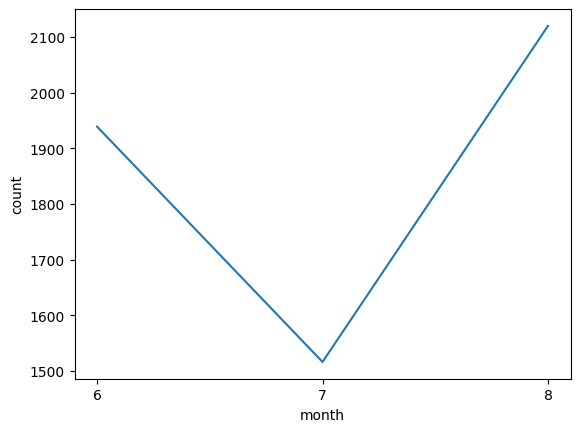

In [192]:
#Изучим, есть ли сезонные колебания в заказах такси. 
# Построим график количества заказов по месяцам и определите месяц с наименьшим количеством заказов летом.


month_count = taxi.groupby('month', as_index=False)['journey_id'].count()\
    .rename(columns={'journey_id': 'count'})\
        .sort_values('count', ascending=False)

summer = month_count.query('month in [6,7,8]')
ax = sns.lineplot(data=summer, x='month', y='count')
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
plt.show()



/var/folders/fy/hf0v9l_j1mn907s1ztzmwcp00000gp/T/ipykernel_8718/1937255061.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=taxi, x='weekday', order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], palette='magma')


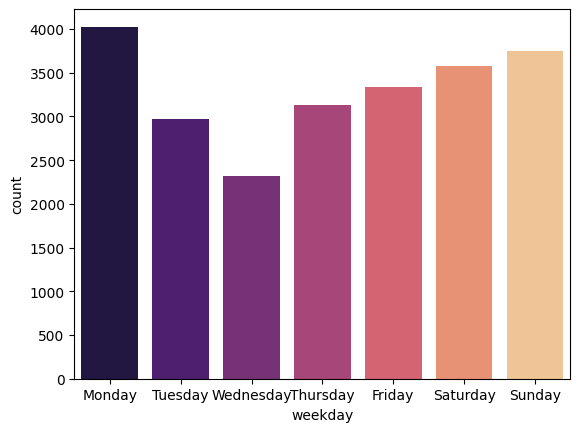

In [191]:
#Сезонность бывает не только внутри года, но и внутри недели. 
# Определим, в какой день недели поступает меньше всего заказов. 
# Укажим то название, которое написано в самом датафрейме.

sns.countplot(data=taxi, x='weekday', order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], palette='magma')
plt.show()




/var/folders/fy/hf0v9l_j1mn907s1ztzmwcp00000gp/T/ipykernel_8718/1816945612.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=DAU, x='month', y='user_id', palette='plasma')


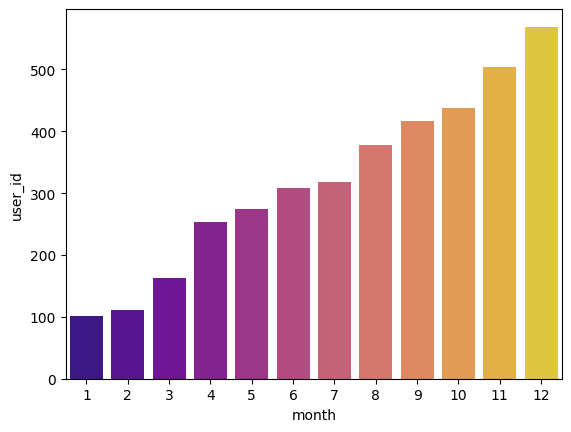

In [211]:
#Познакомимся с часто используемыми метриками, показывающими число активных пользователей за определённый период:
#DAU (daily active users) – число уникальных активных пользователей за день
#WAU (weekly active users) – число уникальных активных пользователей за неделю
#MAU (monthly active users) – число уникальных активных пользователей за месяц
#Активные пользователи – те, кто воспользовался приложением и сделал хотя бы один заказ за выбранный промежуток времени.
#Посчитайте метрику MAU, постройте её график и выберите одно или несколько верных утверждений



DAU = taxi.groupby('month', as_index=False).user_id.nunique()
DAU
sns.barplot(data=DAU, x='month', y='user_id', palette='plasma')
plt.show()



In [ ]:
x = late_table.melt(index='driver_id', values='driver_id')
x

count,1,2,3,4,5,6,7,8,9,11,...,28,33,35,37,42,45,51,57,59,67
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,406921adcca37705ef527b4246c0cfea
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,d665fb9f75ef5d9cd0fd89479380ba78,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,ec84a73745199ff840ecafcb924383ad,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,56f59b58bcbbd1cdabc3652e713134c2,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,c814db2127582cf95dea1f74f43127c2,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,f8cd07f929f6884cd5fea893f4da3461,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
101,784a730957c6e05508e71c604ac92700,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
102,d7bf644eb441cda6127f91addebb85c4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
103,4851ee4c867c9b49b909c1adb76c31e9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
